## Detrending 2m temperature data

Detrend the data, then normalise the residual for GP.

Geopotential units: [m^2 s^-2] \
2m temp units: [K]

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import seasonal_decompose

from GPyTorch.GPRs.utils import freq_spectrum

register_matplotlib_converters()
sns.set_style("darkgrid")

plt.rc("figure", figsize=(8, 6))
plt.rc("font", size=7)

In [3]:
# Data
t2m = xr.open_mfdataset('data/5.625deg/2m_temperature/*.nc', combine='by_coords')
data = t2m.sel(time=slice('2000', '2017'))
point_worst = data['t2m'].sel(lat=65, lon=84.375, method='nearest')
point_best = data['t2m'].sel(lat=2.8125, lon=196.875, method='nearest')

## Global view of the data

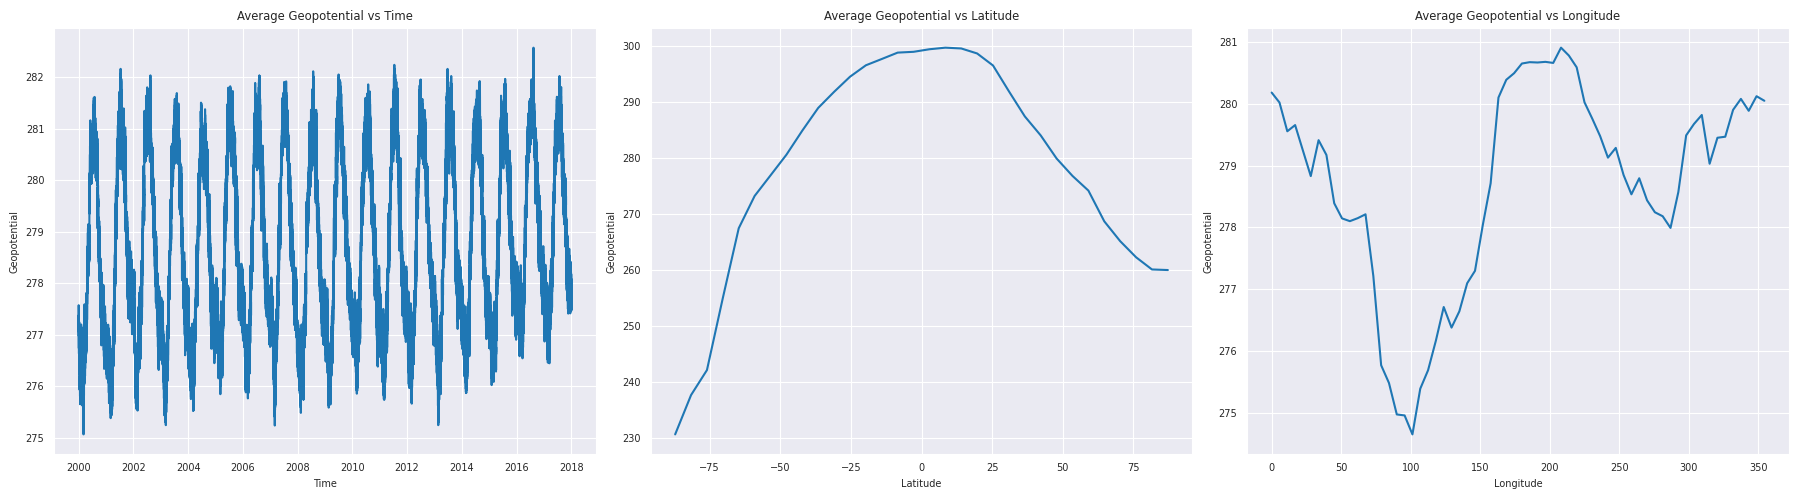

In [ ]:
avg_time = data.t2m.mean(dim=["lat", "lon"])
avg_lat = data.t2m.mean(dim=["time", "lon"])
avg_lon = data.t2m.mean(dim=["time", "lat"])

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

avg_time.plot(ax=axs[0])
axs[0].set_title("Average 2m-temp vs Time")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("2m-temp")

avg_lat.plot(ax=axs[1])
axs[1].set_title("Average 2m-temp vs Latitude")
axs[1].set_xlabel("Latitude")
axs[1].set_ylabel("2m-temp")

avg_lon.plot(ax=axs[2])
axs[2].set_title("Average 2m-temp vs Longitude")
axs[2].set_xlabel("Longitude")
axs[2].set_ylabel("2m-temp")

plt.tight_layout()
plt.show()

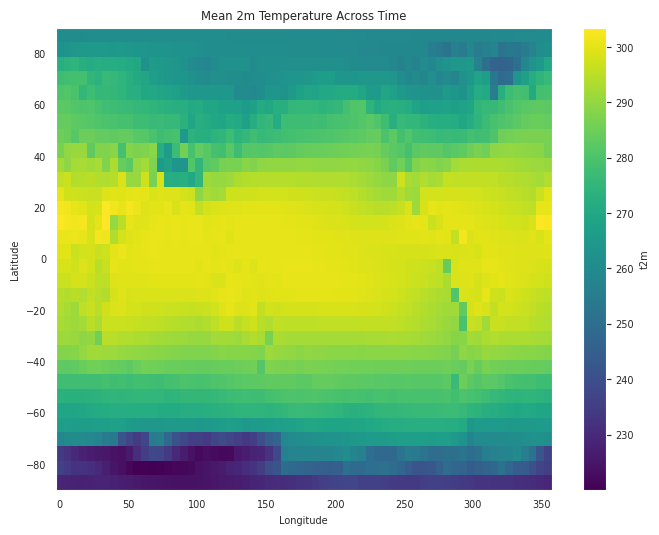

In [6]:
mean_z = data.t2m.mean(dim='time')

mean_z.plot(cmap='viridis')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean 2m Temperature Across Time")
plt.show()

We can use periodogram to extract possible periodicity

We first analyse the worst point

In [6]:
periods = freq_spectrum(point_worst, plot=False)
detrend_point_worst = seasonal_decompose(point_worst, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst.plot()
plt.show()
resid_point_worst = detrend_point_worst.resid
detrend_point_worst = detrend_point_worst.trend+detrend_point_worst.seasonal

NameError: name 'freq_spectrum' is not defined

Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 hrs = 1.00 days = 0.03 months), power = 3.64856 * 1e5
Peak at frequency = 0.00042 cycles/hour (corresponding period = 2401.64 hrs = 100.07 days = 3.34 months), power = 1.05956 * 1e5
Peak at frequency = 0.00006 cycles/hour (corresponding period = 15938.18 hrs = 664.09 days = 22.14 months), power = 0.92257 * 1e5
Peak at frequency = 0.04178 cycles/hour (corresponding period = 23.93 hrs = 1.00 days = 0.03 months), power = 0.89888 * 1e5
Peak at frequency = 0.00106 cycles/hour (corresponding period = 947.68 hrs = 39.49 days = 1.32 months), power = 0.82334 * 1e5


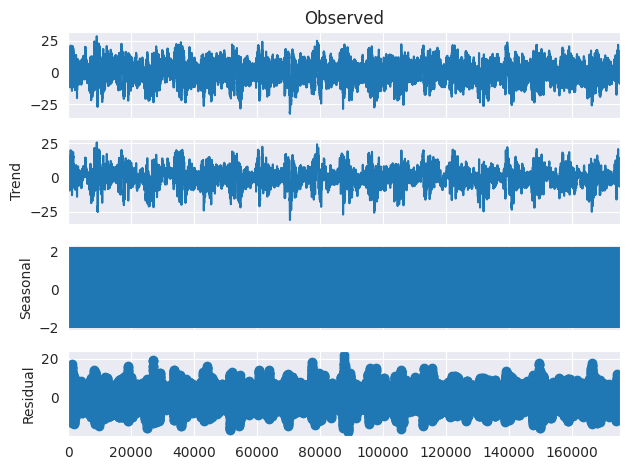

In [6]:
periods = freq_spectrum(resid_point_worst, plot=False)
detrend_point_worst2 = seasonal_decompose(resid_point_worst, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst2.plot()
plt.show()
resid_point_worst2 = detrend_point_worst2.resid
detrend_point_worst2 = detrend_point_worst2.trend+detrend_point_worst2.seasonal+detrend_point_worst

In [7]:
periods = freq_spectrum(resid_point_worst2, plot=False)

Peak at frequency = 0.04178 cycles/hour (corresponding period = 23.93 hrs = 1.00 days = 0.03 months), power = 0.89374 * 1e5
Peak at frequency = 0.04155 cycles/hour (corresponding period = 24.07 hrs = 1.00 days = 0.03 months), power = 0.52465 * 1e5
Peak at frequency = 0.04144 cycles/hour (corresponding period = 24.13 hrs = 1.01 days = 0.03 months), power = 0.08412 * 1e5
Peak at frequency = 0.00888 cycles/hour (corresponding period = 112.67 hrs = 4.69 days = 0.16 months), power = 0.04100 * 1e5
Peak at frequency = 0.08356 cycles/hour (corresponding period = 11.97 hrs = 0.50 days = 0.02 months), power = 0.03017 * 1e5


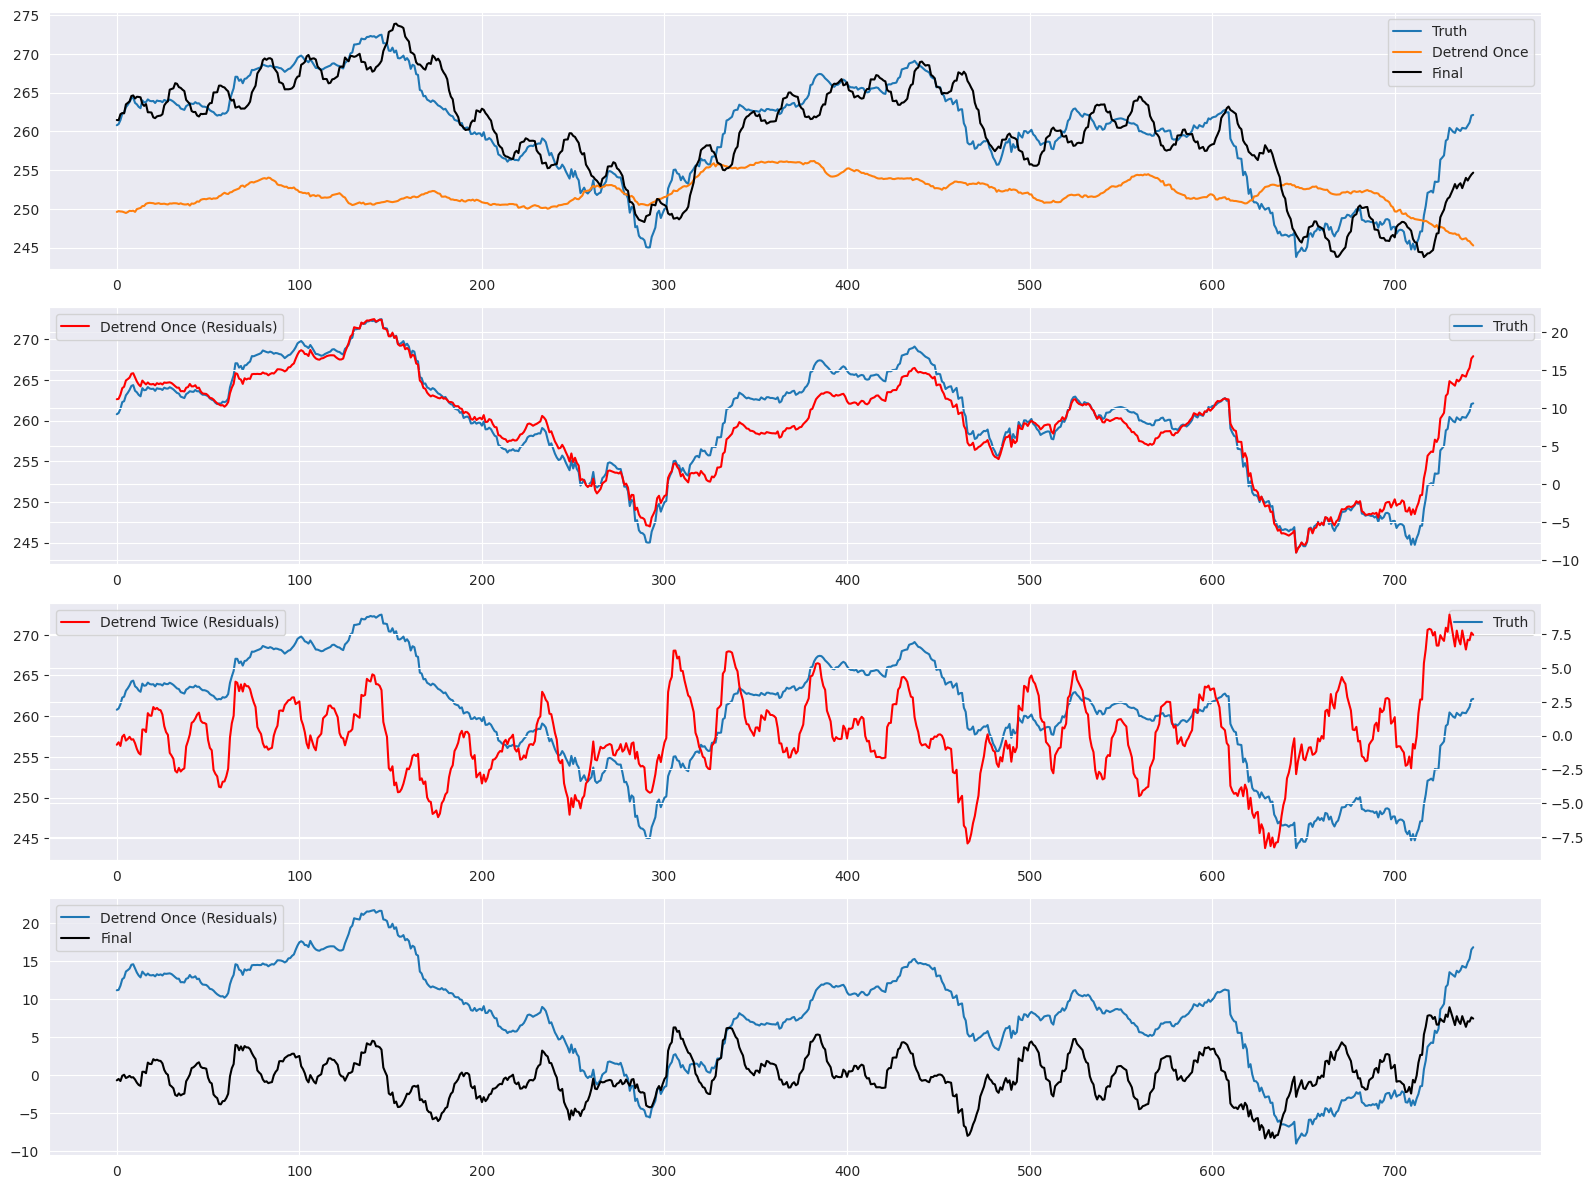

In [8]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(16, 12))
axs[0].plot(point_worst.values[-744:], label="Truth")
axs[0].plot(detrend_point_worst[-744:], label="Detrend Once")
axs[0].plot(detrend_point_worst2[-744:], color='black', label="Final")
axs[0].legend()

axs[1].plot(point_worst.values[-744:], label="Truth")
ax1 = axs[1].twinx()
ax1.plot(resid_point_worst[-744:], color='red', label='Detrend Once (Residuals)')
ax1.legend(loc='upper left')
axs[1].legend()

axs[2].plot(point_worst.values[-744:], label="Truth")
ax2 = axs[2].twinx()
ax2.plot(resid_point_worst2[-744:], color='red', label='Detrend Twice (Residuals)')
ax2.legend(loc='upper left')
axs[2].legend()

axs[3].plot(resid_point_worst[-744:], label="Detrend Once (Residuals)")
axs[3].plot(resid_point_worst2[-744:], color='black', label='Final')
axs[3].legend()

fig.tight_layout()
plt.show()

Peak at frequency = 0.00001 cycles/hour (corresponding period = 87660.00 hrs = 3652.50 days = 121.75 months), power = 0.20417 * 1e5
Peak at frequency = 0.00011 cycles/hour (corresponding period = 8766.00 hrs = 365.25 days = 12.18 months), power = 0.14123 * 1e5
Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 hrs = 1.00 days = 0.03 months), power = 0.04987 * 1e5
Peak at frequency = 0.00023 cycles/hour (corresponding period = 4383.00 hrs = 182.62 days = 6.09 months), power = 0.01551 * 1e5
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs = 0.50 days = 0.02 months), power = 0.00401 * 1e5


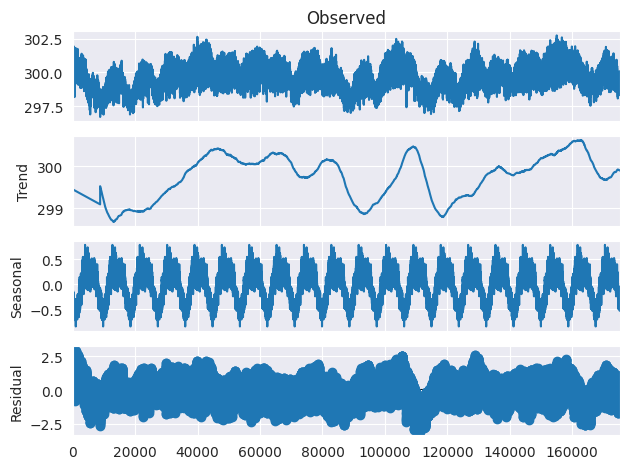

In [14]:
periods = freq_spectrum(point_best, plot=False)
detrend_point_best = seasonal_decompose(point_best, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_best.plot()
plt.show()
resid_point_best = detrend_point_best.resid
detrend_point_best = detrend_point_best.trend+detrend_point_best.seasonal

In [15]:
periods = freq_spectrum(resid_point_best, plot=False)
detrend_point_best2 = seasonal_decompose(resid_point_best, period=24, two_sided=False, extrapolate_trend='freq')
resid_point_best2 = detrend_point_best2.resid
detrend_point_best2 = detrend_point_best2.trend+detrend_point_best2.seasonal+detrend_point_best

Peak at frequency = 0.00004 cycles/hour (corresponding period = 25045.71 hrs = 1043.57 days = 34.79 months), power = 0.07957 * 1e5
Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 hrs = 1.00 days = 0.03 months), power = 0.04984 * 1e5
Peak at frequency = 0.00010 cycles/hour (corresponding period = 10312.94 hrs = 429.71 days = 14.32 months), power = 0.03803 * 1e5
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs = 0.50 days = 0.02 months), power = 0.00400 * 1e5
Peak at frequency = 0.00017 cycles/hour (corresponding period = 5844.00 hrs = 243.50 days = 8.12 months), power = 0.00370 * 1e5


In [11]:
periods = freq_spectrum(resid_point_best2, plot=False)
detrend_point_best3 = seasonal_decompose(resid_point_best2, period=periods, two_sided=False, extrapolate_trend='freq')
resid_point_best3 = detrend_point_best3.resid
detrend_point_best3 = detrend_point_best3.trend+detrend_point_best3.seasonal+detrend_point_best

Peak at frequency = 0.00007 cycles/hour (corresponding period = 13486.15 hrs = 561.92 days = 18.73 months), power = 0.05579 * 1e5
Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 hrs = 1.00 days = 0.03 months), power = 0.04971 * 1e5
Peak at frequency = 0.00001 cycles/hour (corresponding period = 87660.00 hrs = 3652.50 days = 121.75 months), power = 0.01043 * 1e5
Peak at frequency = 0.00014 cycles/hour (corresponding period = 7012.80 hrs = 292.20 days = 9.74 months), power = 0.00471 * 1e5
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs = 0.50 days = 0.02 months), power = 0.00385 * 1e5


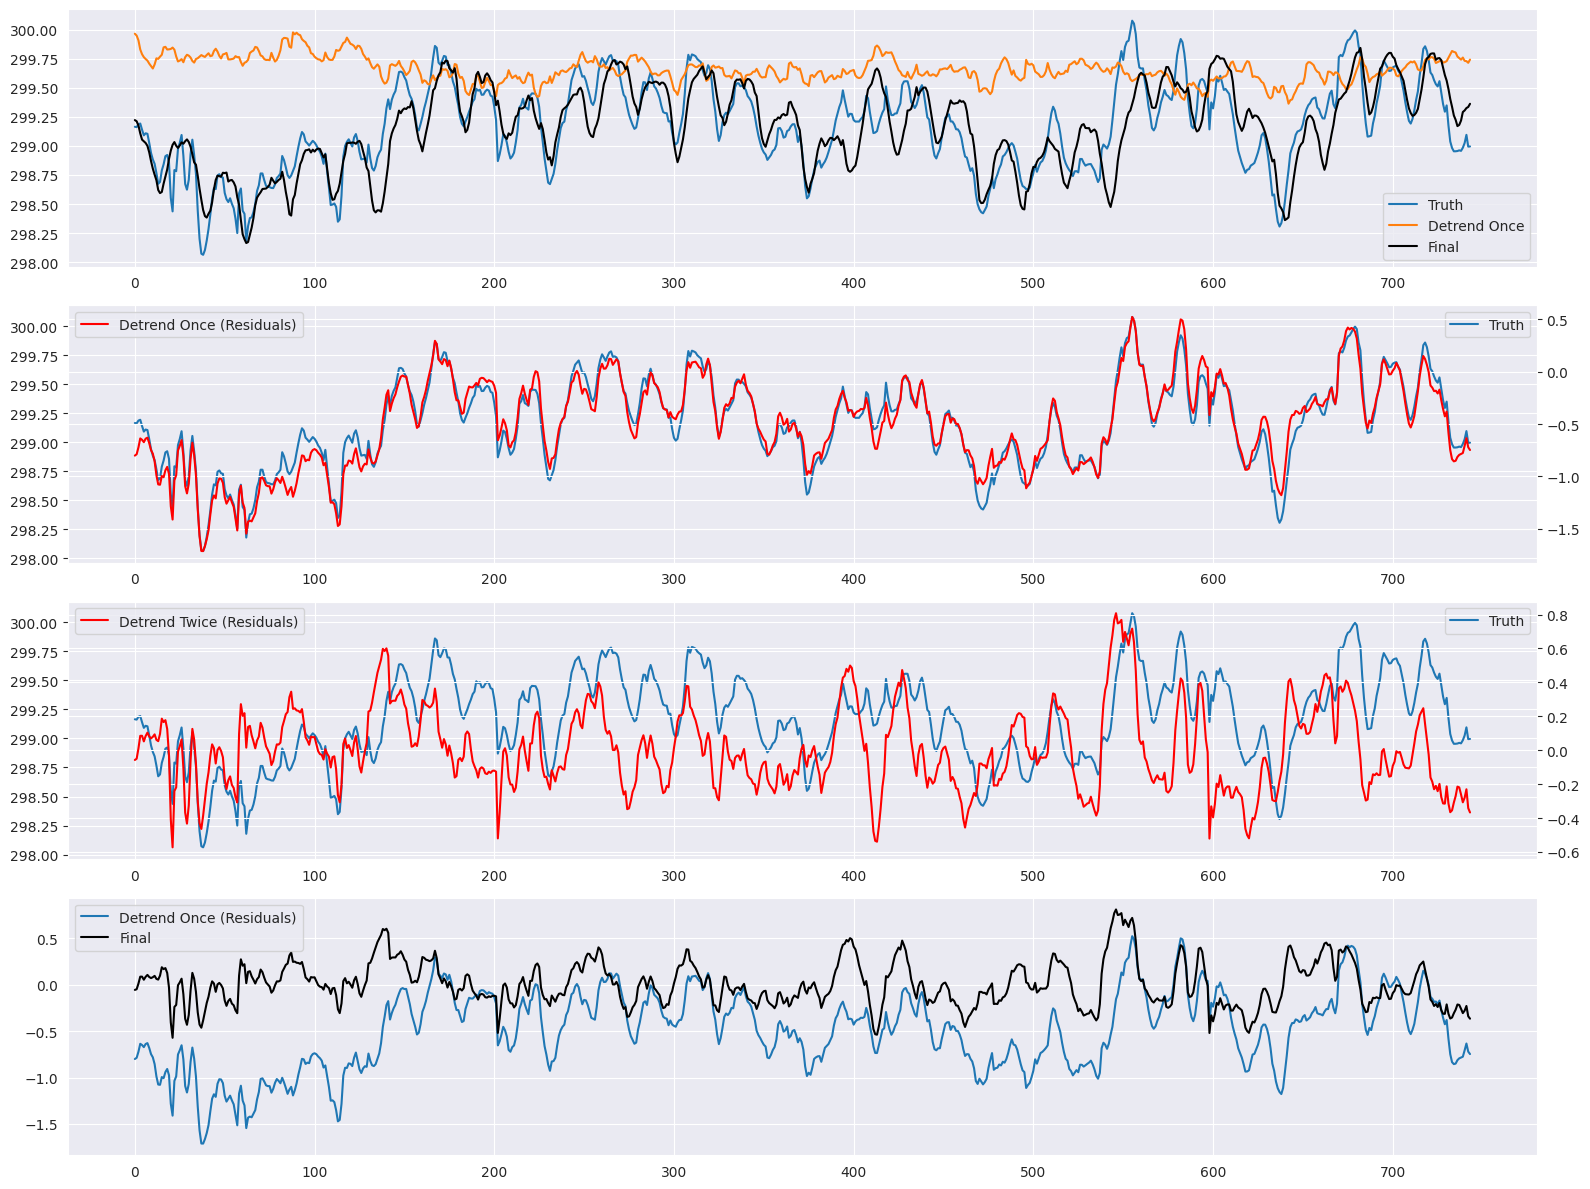

In [16]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(16, 12))
axs[0].plot(point_best.values[-744:], label="Truth")
axs[0].plot(detrend_point_best[-744:], label="Detrend Once")
axs[0].plot(detrend_point_best2[-744:], color='black', label="Final")
axs[0].legend()

axs[1].plot(point_best.values[-744:], label="Truth")
ax1 = axs[1].twinx()
ax1.plot(resid_point_best[-744:], color='red', label='Detrend Once (Residuals)')
ax1.legend(loc='upper left')
axs[1].legend()

axs[2].plot(point_best.values[-744:], label="Truth")
ax2 = axs[2].twinx()
ax2.plot(resid_point_best2[-744:], color='red', label='Detrend Twice (Residuals)')
ax2.legend(loc='upper left')
axs[2].legend()

axs[3].plot(resid_point_best[-744:], label="Detrend Once (Residuals)")
axs[3].plot(resid_point_best2[-744:], color='black', label='Final')
axs[3].legend()

fig.tight_layout()
plt.show()

[]

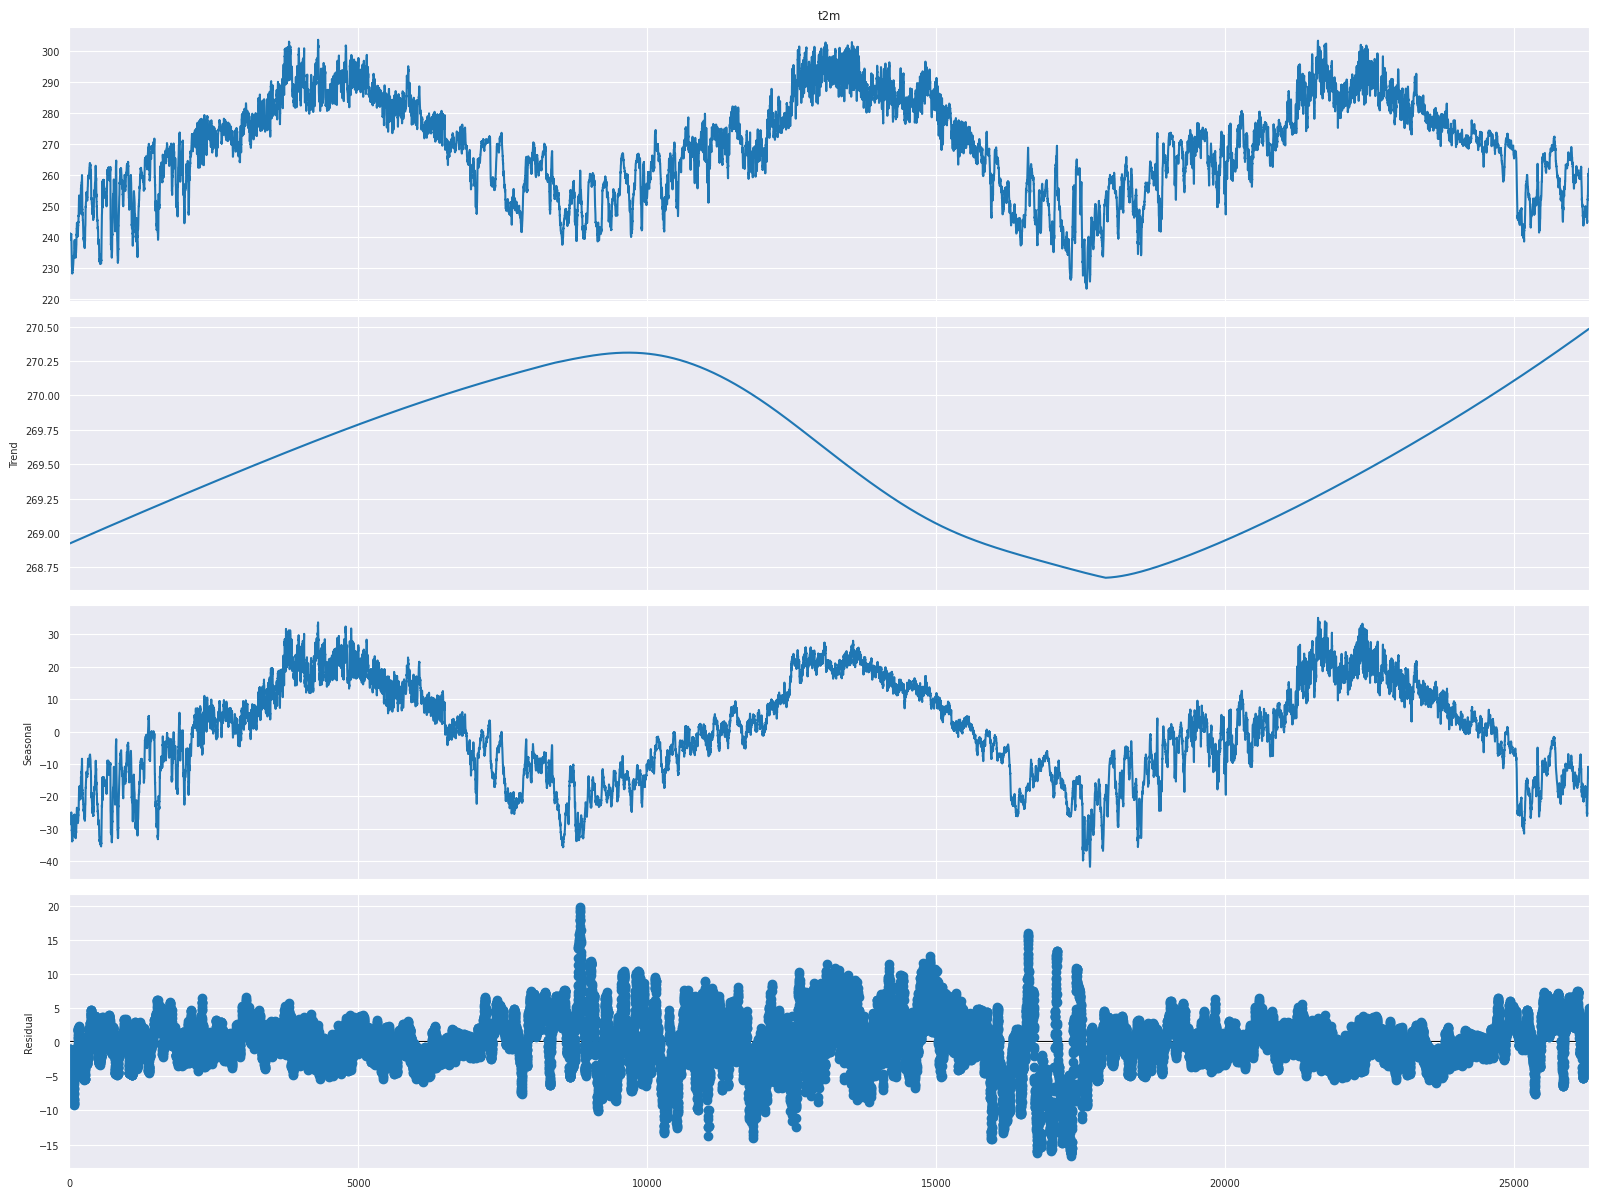

In [ ]:
train_detrend_point_worst = STL(point_worst, period=8768)
train_residual_point_worst = train_detrend_point_worst.fit()
train_residual_point_worst.plot()
plt.plot()

[]

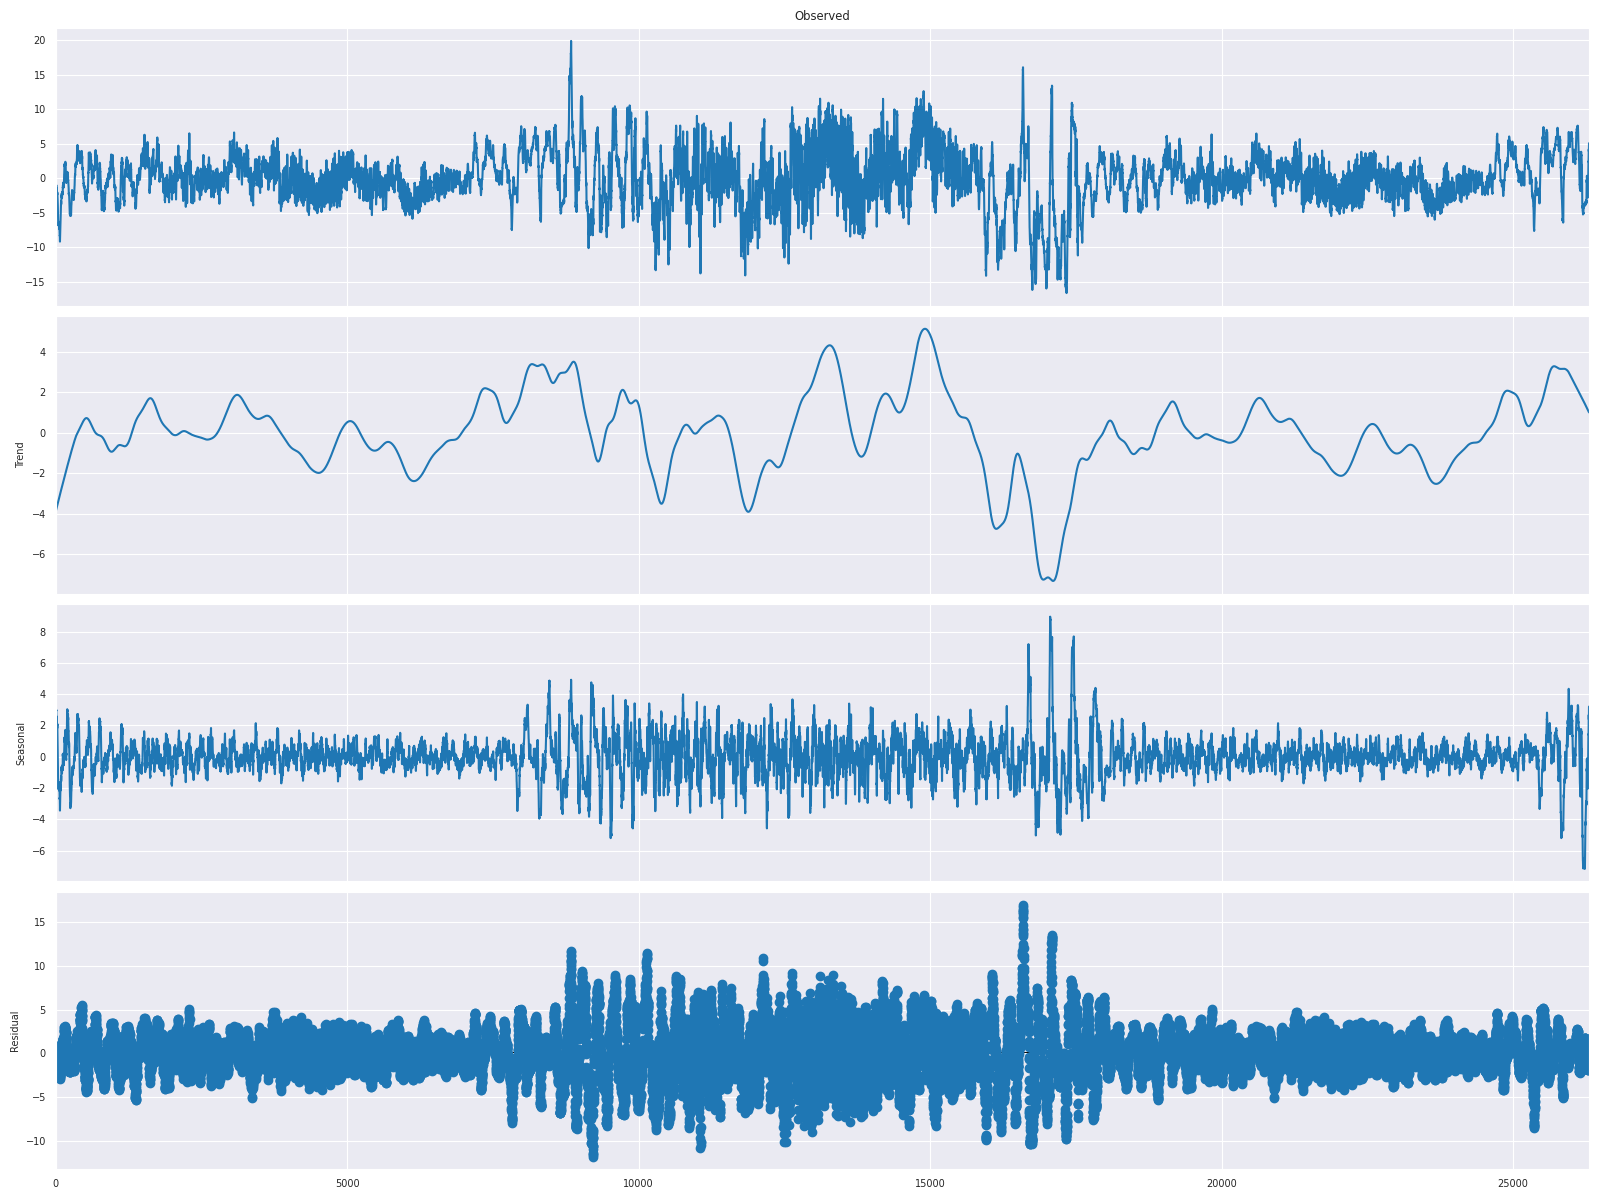

In [ ]:
train_detrend2_point_worst = STL(train_residual_point_worst.resid, period=372)
train_residual2_point_worst = train_detrend2_point_worst.fit()
train_residual2_point_worst.plot()
plt.plot()

In [ ]:
detrend3 = train_residual2_point_worst.resid[25560:]
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend3, fs=fs)
peaks, properties = find_peaks(power, height=1, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.00941 cycles/hour (corresponding period = 106.29 hrs = 4.43 days = 0.15 months), power = 406.63806
Peak at frequency = 0.00403 cycles/hour (corresponding period = 248.00 hrs = 10.33 days = 0.34 months), power = 403.66620
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 146.17274
Peak at frequency = 0.01478 cycles/hour (corresponding period = 67.64 hrs = 2.82 days = 0.09 months), power = 82.32120
Peak at frequency = 0.01210 cycles/hour (corresponding period = 82.67 hrs = 3.44 days = 0.11 months), power = 81.96453
Peak at frequency = 0.02016 cycles/hour (corresponding period = 49.60 hrs = 2.07 days = 0.07 months), power = 58.45227
Peak at frequency = 0.02823 cycles/hour (corresponding period = 35.43 hrs = 1.48 days = 0.05 months), power = 41.52661
Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 19.89944


[]

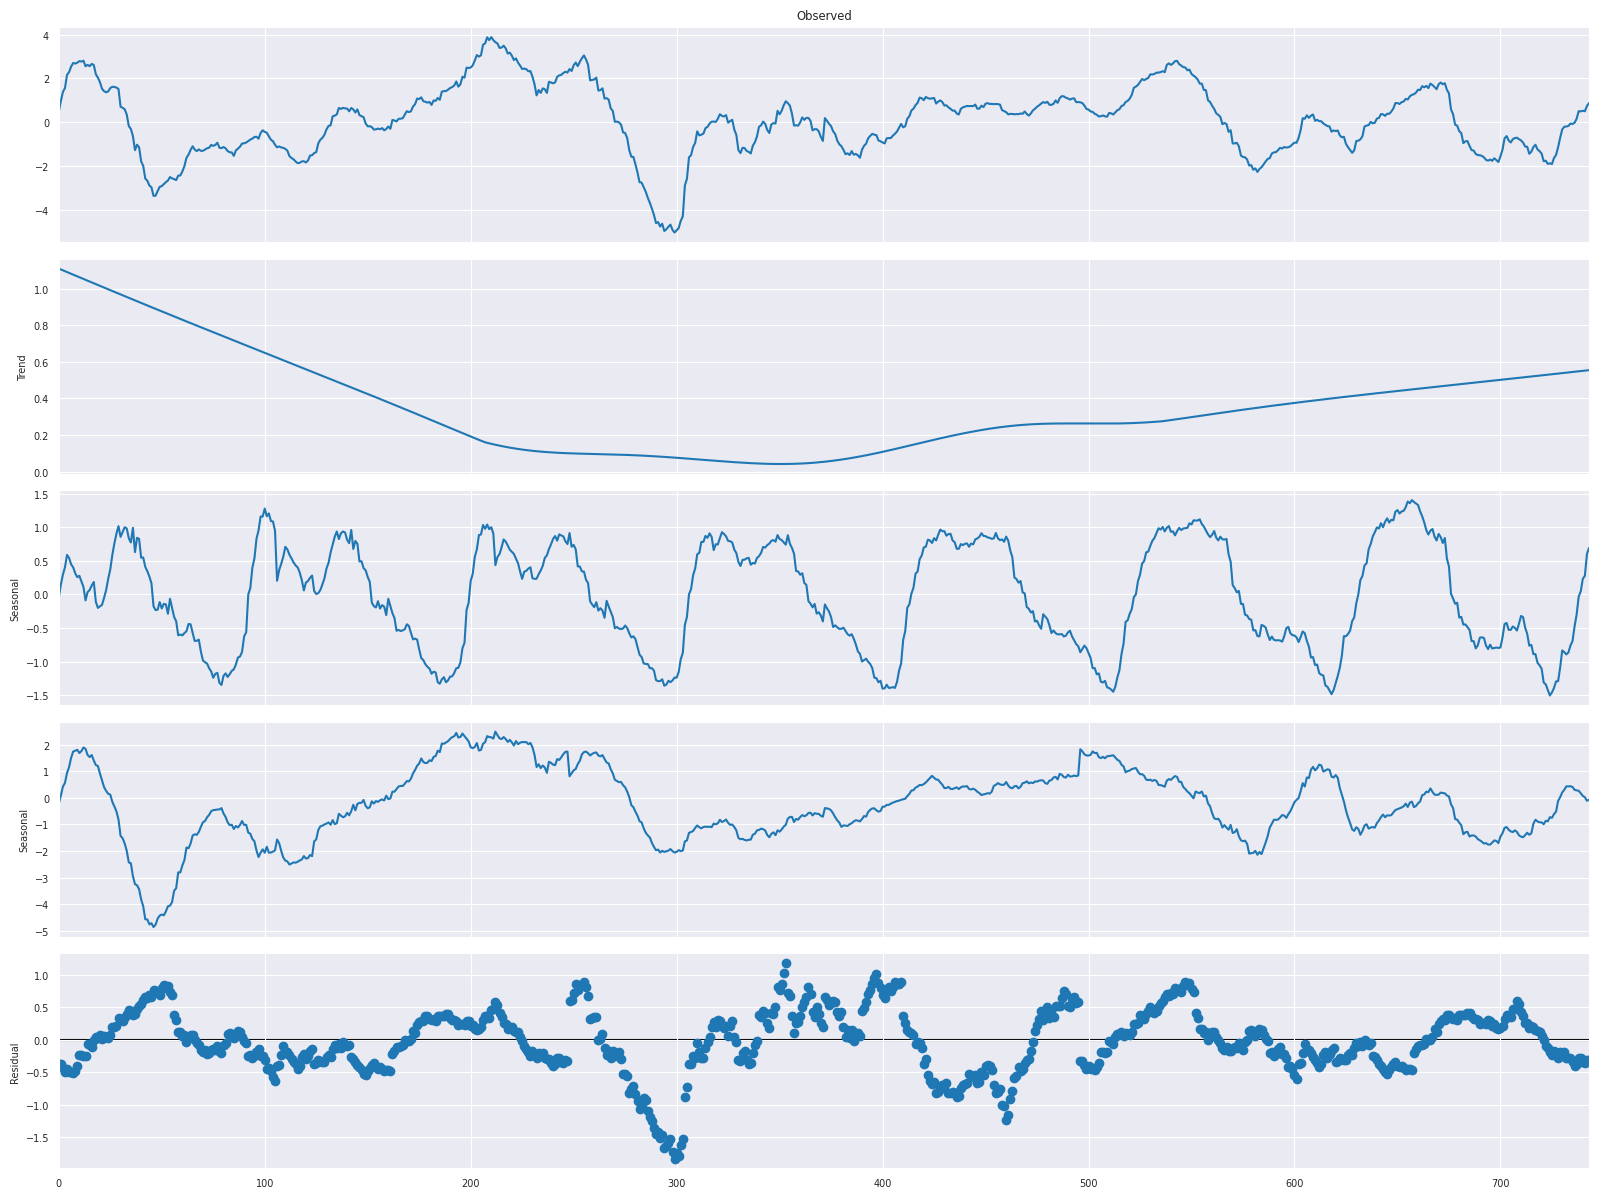

In [ ]:
train_detrend3_point_worst = MSTL(detrend3, periods=[106, 248])
train_residual3_point_worst = train_detrend3_point_worst.fit()
train_residual3_point_worst.plot()
plt.plot()

In [ ]:
detrend4 = train_residual3_point_worst.resid
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend4, fs=fs)
peaks, properties = find_peaks(power, height=1, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.00672 cycles/hour (corresponding period = 148.80 hrs = 6.20 days = 0.21 months), power = 49.70117
Peak at frequency = 0.01344 cycles/hour (corresponding period = 74.40 hrs = 3.10 days = 0.10 months), power = 23.58498
Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 8.41650
Peak at frequency = 0.00941 cycles/hour (corresponding period = 106.29 hrs = 4.43 days = 0.15 months), power = 7.61821
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 3.93498
Peak at frequency = 0.03091 cycles/hour (corresponding period = 32.35 hrs = 1.35 days = 0.04 months), power = 3.24470
Peak at frequency = 0.02554 cycles/hour (corresponding period = 39.16 hrs = 1.63 days = 0.05 months), power = 3.18390
Peak at frequency = 0.03360 cycles/hour (corresponding period = 29.76 hrs = 1.24 days = 0.04 months), power = 1.56321


[]

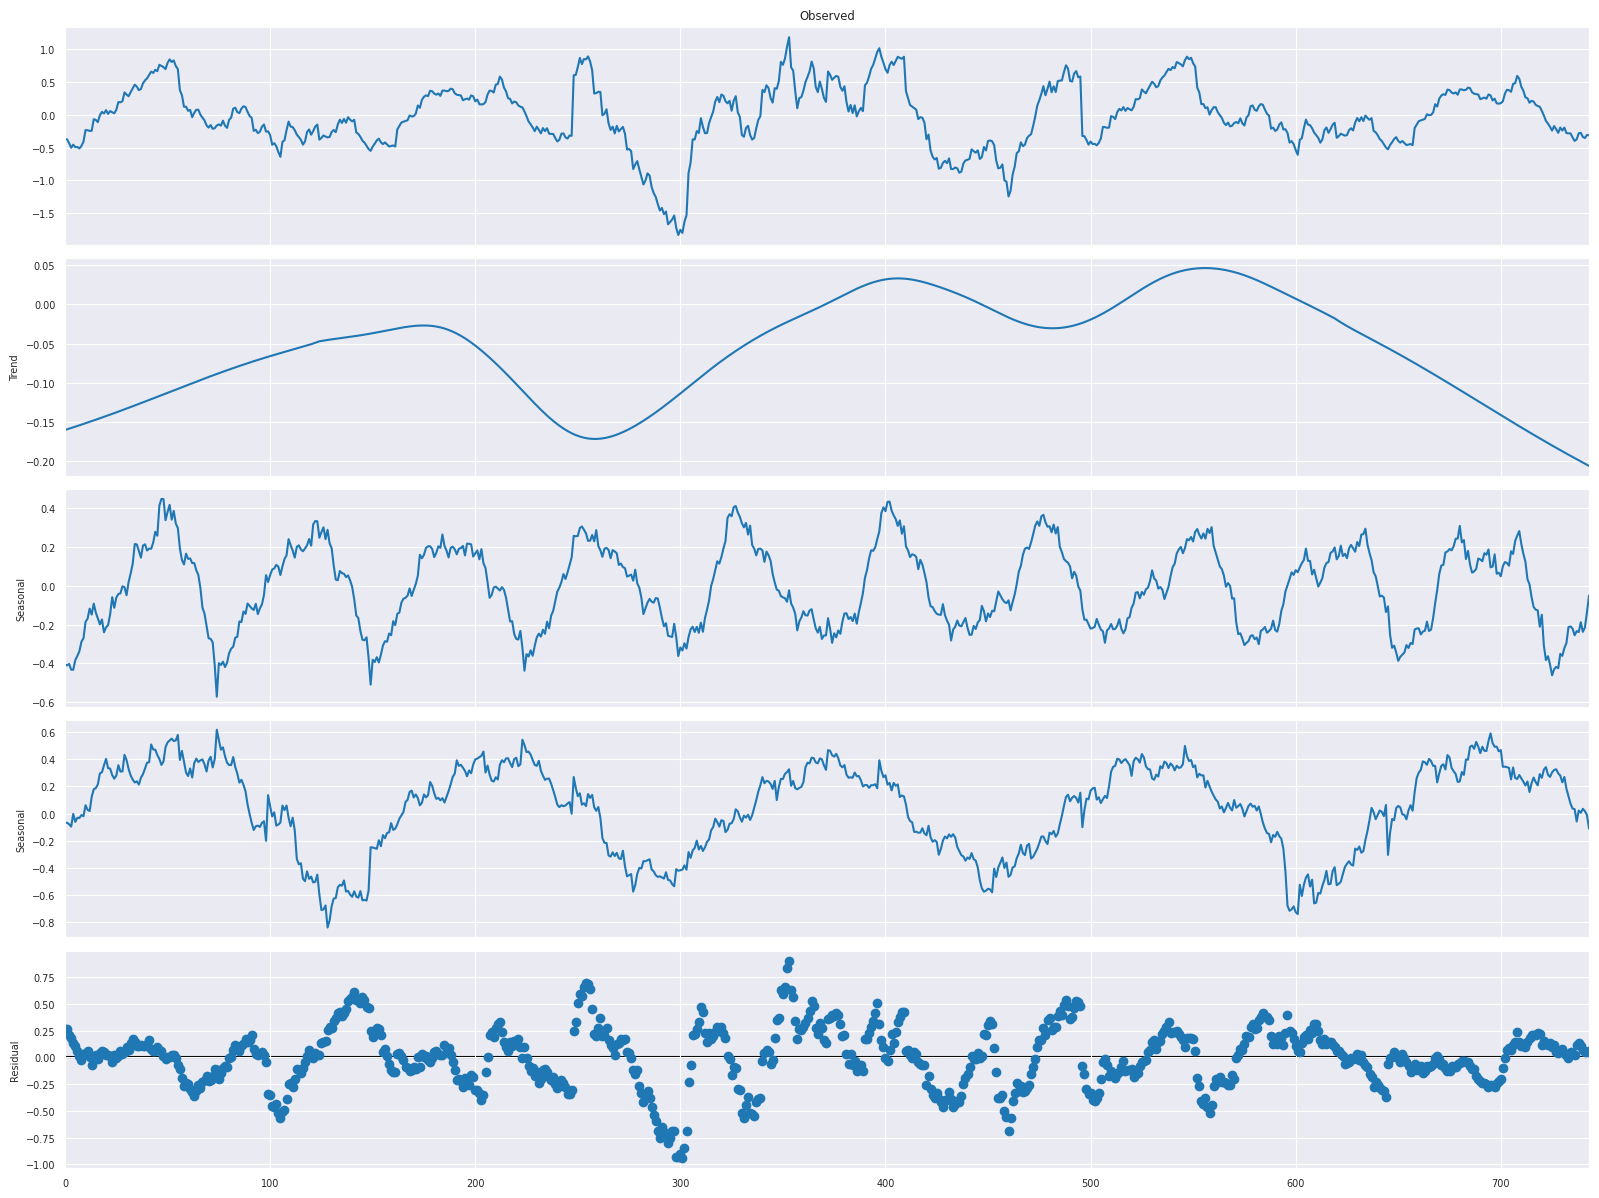

In [ ]:
train_detrend4_point_worst = MSTL(detrend4, periods=[75, 149])
train_residual4_point_worst = train_detrend4_point_worst.fit()
train_residual4_point_worst.plot()
plt.plot()

In [ ]:
detrend5 = train_residual4_point_worst.resid
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(detrend5, fs=fs)
peaks, properties = find_peaks(power, height=0, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:8]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")

Peak at frequency = 0.02285 cycles/hour (corresponding period = 43.76 hrs = 1.82 days = 0.06 months), power = 9.05276
Peak at frequency = 0.00806 cycles/hour (corresponding period = 124.00 hrs = 5.17 days = 0.17 months), power = 7.28334
Peak at frequency = 0.01747 cycles/hour (corresponding period = 57.23 hrs = 2.38 days = 0.08 months), power = 6.41542
Peak at frequency = 0.00538 cycles/hour (corresponding period = 186.00 hrs = 7.75 days = 0.26 months), power = 3.94761
Peak at frequency = 0.02957 cycles/hour (corresponding period = 33.82 hrs = 1.41 days = 0.05 months), power = 3.10378
Peak at frequency = 0.01478 cycles/hour (corresponding period = 67.64 hrs = 2.82 days = 0.09 months), power = 1.67481
Peak at frequency = 0.04301 cycles/hour (corresponding period = 23.25 hrs = 0.97 days = 0.03 months), power = 0.90532
Peak at frequency = 0.07124 cycles/hour (corresponding period = 14.04 hrs = 0.58 days = 0.02 months), power = 0.83431


[]

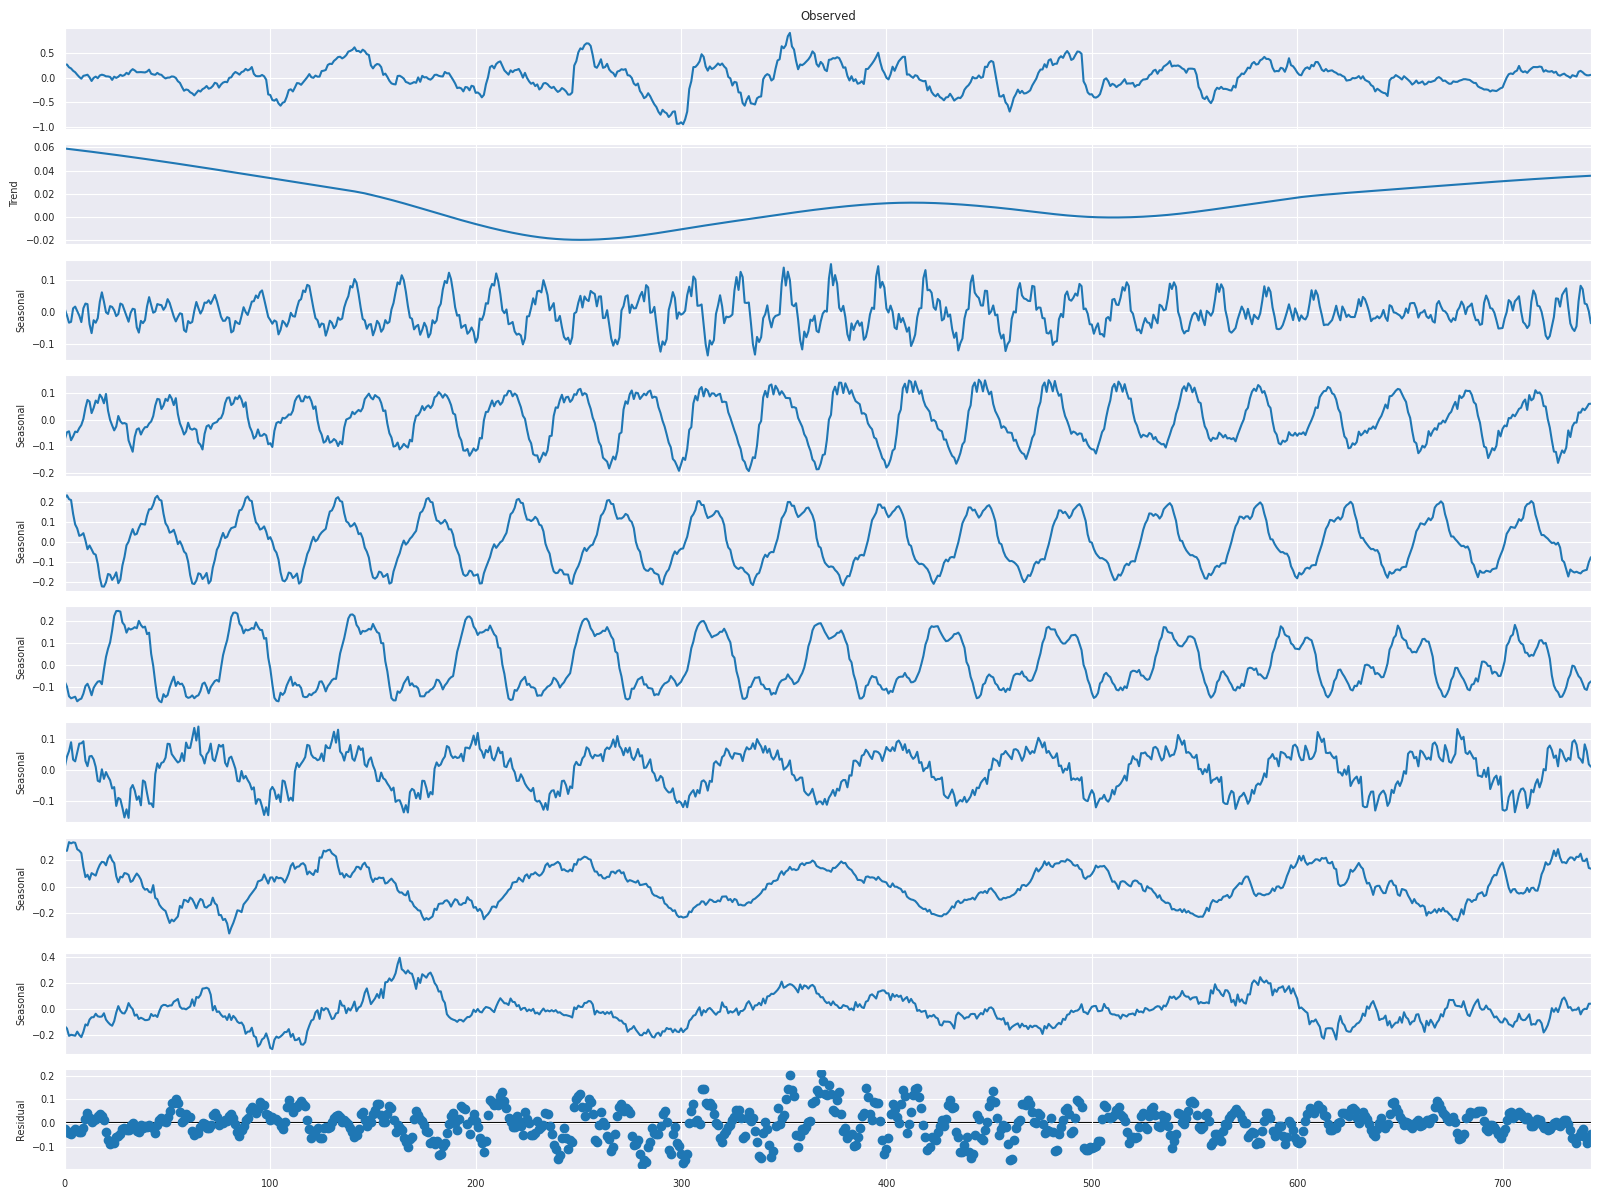

In [ ]:
train_detrend5_point_worst = MSTL(detrend5, periods=[23, 34, 44, 57, 68, 124, 186])
train_residual5_point_worst = train_detrend5_point_worst.fit()
train_residual5_point_worst.plot()
plt.plot()

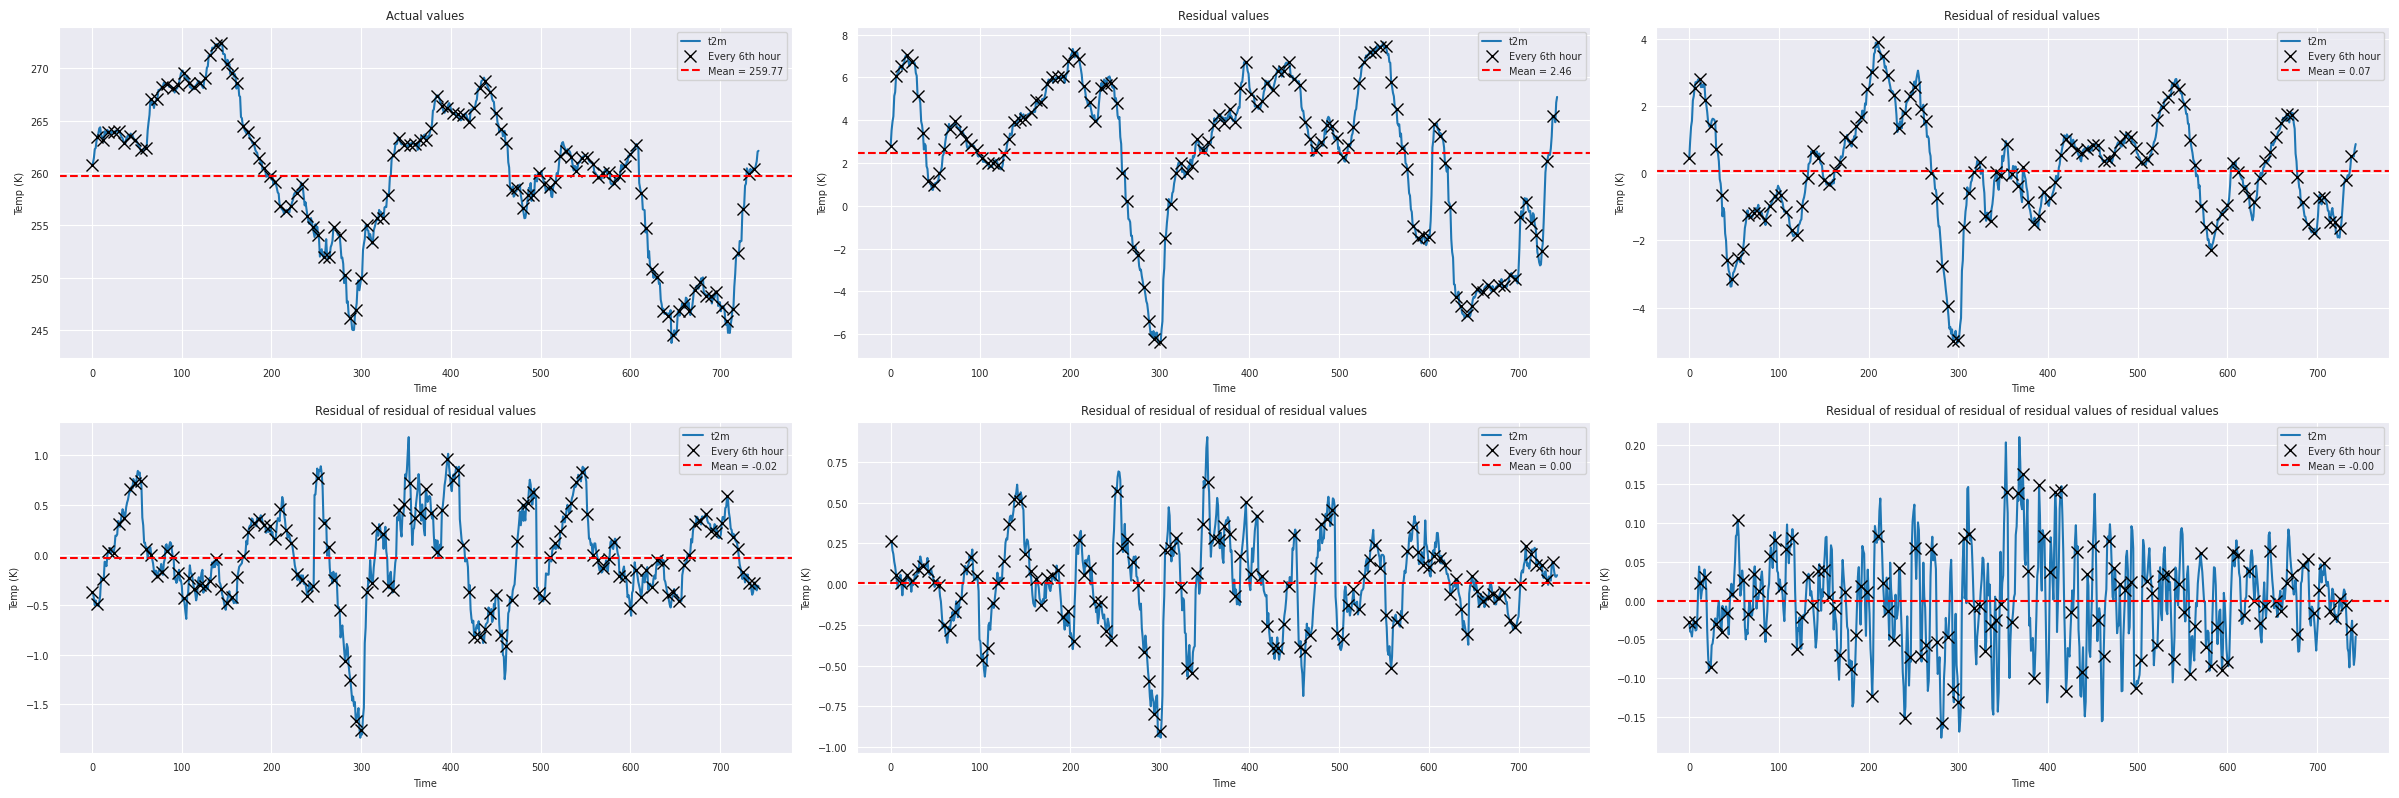

In [ ]:
data_segment = point_worst.values[25560:]
x = np.arange(len(data_segment))

fig, axes = plt.subplots(2, 3, figsize=(24, 8))
mean_value = np.mean(data_segment)
axes[0][0].plot(x, data_segment, label="t2m")
axes[0][0].plot(x[::6], data_segment[::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][0].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][0].set_title("Actual values")
axes[0][0].set_xlabel("Time")
axes[0][0].set_ylabel("Temp (K)")
axes[0][0].legend()

# Plot on the second subplot
mean_value = np.mean(train_residual_point_worst.resid[25560:])
axes[0][1].plot(x, train_residual_point_worst.resid[25560:], label="t2m")
axes[0][1].plot(x[::6], train_residual_point_worst.resid[25560:][::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][1].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][1].set_title("Residual values")
axes[0][1].set_xlabel("Time")
axes[0][1].set_ylabel("Temp (K)")
axes[0][1].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual2_point_worst.resid[25560:])
axes[0][2].plot(x, train_residual2_point_worst.resid[25560:], label="t2m")
axes[0][2].plot(x[::6], train_residual2_point_worst.resid[25560:][::6], 'kx', markersize=8, label="Every 6th hour")
axes[0][2].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[0][2].set_title("Residual of residual values")
axes[0][2].set_xlabel("Time")
axes[0][2].set_ylabel("Temp (K)")
axes[0][2].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual3_point_worst.resid)
axes[1][0].plot(x, train_residual3_point_worst.resid, label="t2m")
axes[1][0].plot(x[::6], train_residual3_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][0].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][0].set_title("Residual of residual of residual values")
axes[1][0].set_xlabel("Time")
axes[1][0].set_ylabel("Temp (K)")
axes[1][0].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual4_point_worst.resid)
axes[1][1].plot(x, train_residual4_point_worst.resid, label="t2m")
axes[1][1].plot(x[::6], train_residual4_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][1].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][1].set_title("Residual of residual of residual of residual values")
axes[1][1].set_xlabel("Time")
axes[1][1].set_ylabel("Temp (K)")
axes[1][1].legend()

# Plot on the third subplot
mean_value = np.mean(train_residual5_point_worst.resid)
axes[1][2].plot(x, train_residual5_point_worst.resid, label="t2m")
axes[1][2].plot(x[::6], train_residual5_point_worst.resid[::6], 'kx', markersize=8, label="Every 6th hour")
axes[1][2].axhline(mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
axes[1][2].set_title("Residual of residual of residual of residual values of residual values")
axes[1][2].set_xlabel("Time")
axes[1][2].set_ylabel("Temp (K)")
axes[1][2].legend()


plt.tight_layout()
plt.show()

In [ ]:
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_best.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:6]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

In [ ]:
detrend_point_best = MSTL(point_best, periods=[24, 148])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()
plt.plot()